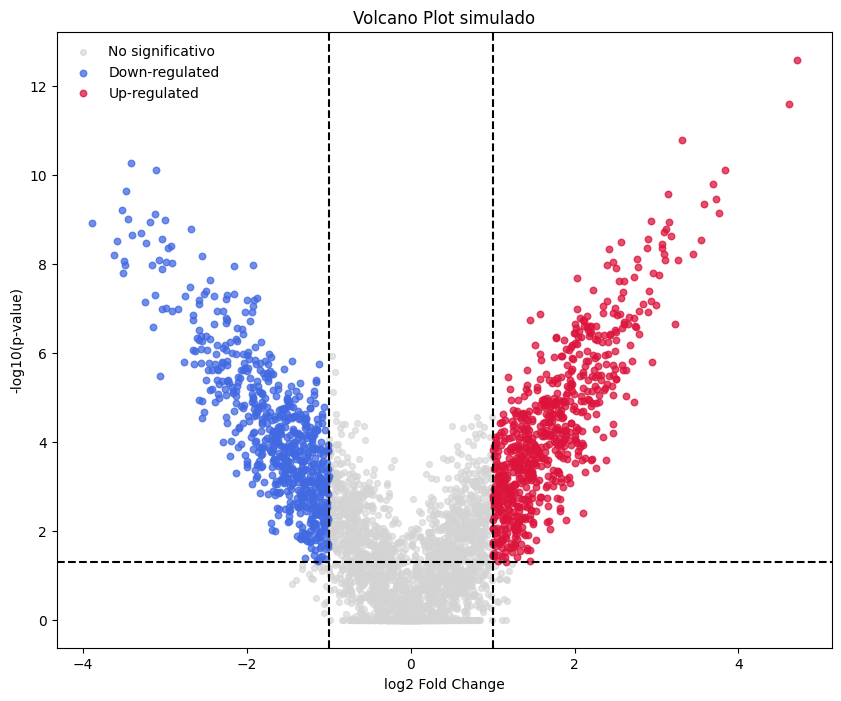

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Número total de genes
n = 3500

# Fold changes simulados
log2fc = np.random.normal(0, 1.2, n)

# Generar p-values dependientes del tamaño del efecto
# (más lejos de 0 -> más significativos)
signal = np.abs(log2fc)

neglog10p = (
    signal * 2.5 +
    np.random.normal(0, 1.0, n)
)

neglog10p = np.clip(neglog10p, 0, None)

pvalue = 10**(-neglog10p)

# Clasificación
up = (log2fc > 1) & (pvalue < 0.05)
down = (log2fc < -1) & (pvalue < 0.05)
ns = ~(up | down)

# Figura
plt.figure(figsize=(10,8))

plt.scatter(
    log2fc[ns],
    neglog10p[ns],
    c='lightgray',
    s=18,
    alpha=0.6,
    label='No significativo'
)

plt.scatter(
    log2fc[down],
    neglog10p[down],
    c='royalblue',
    s=22,
    alpha=0.75,
    label='Down-regulated'
)

plt.scatter(
    log2fc[up],
    neglog10p[up],
    c='crimson',
    s=22,
    alpha=0.75,
    label='Up-regulated'
)

plt.axvline(-1, ls='--', c='black')
plt.axvline(1, ls='--', c='black')
plt.axhline(-np.log10(0.05), ls='--', c='black')

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot simulado")
plt.legend(frameon=False)

plt.show()